In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

env = gym.make("CartPole-v1")

In [2]:
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

state, _ = env.reset()
print("Sample state:", state)

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Sample state: [ 0.04473132  0.0083104   0.01981355 -0.00802454]


In [ ]:
class MDPCartPole:
    def __init__(self, env, n_buckets=10, n_samples=10000, progress_every=1000):
        self.env = env
        # n_buckets: so bin moi chieu; n_samples: so episode de lay mau
        self.n_buckets = n_buckets
        self.n_samples = n_samples
        self.n_actions = env.action_space.n
        # in tien do uoc luong model moi progress_every episode
        self.progress_every = progress_every

        # Tao buckets de discretize state
        self.buckets = self._create_buckets()

        # Transition model (dem so lan chuyen tiep + tong reward)
        #{(state, action): {next_state: (count, total_reward)}}
        self.transitions = defaultdict(
            lambda: defaultdict(lambda: [0,0.0])
        )

        # value function va policy
        self.V = defaultdict(float)
        self.policy = defaultdict(int)

        # estimate model from samples
        print("Estimate model from sample...")
        self._estimate_model()
        print("Number of buckets per dimension:", self.n_buckets)
    
    # xác định cách chia không gian trạng thái liên tục thành các phần nhỏ (bins/buckets)
    def _create_buckets(self):
        # Giới hạn quan sát cho CartPole
        bounds = [
            (-4.8, 4.8),        # cart position
            (-3.0, 3.0),        # cart velocity
            (-0.418, 0.418),    # pole angle
            (-3.0, 3.0)         # pole velocity
        ]
        buckets = []
        for low, high in bounds:
            # Use internal boundaries so digitize returns 0..n_buckets-1
            boundaries = np.linspace(low, high, self.n_buckets + 1)[1:-1]
            buckets.append(boundaries)
        return buckets

    # biến đổi trạng thái từ liên tục sang rời rạc (chi so bin 0..n_buckets-1)
    def discretize_state(self, state):
        discrete = []

        for i in range(len(state)):
            bucket_index = int(np.digitize(state[i], self.buckets[i]))
            # Đảm bảo chỉ số của thùng luôn nằm trong khoảng từ 0 đến n_buckets - 1 để tránh lỗi truy xuất mảng
            bucket_index = min(max(bucket_index, 0), self.n_buckets - 1)

            discrete.append(bucket_index)
        return tuple(discrete)
    
    # thu thập dữ liệu thực tế để xây dựng "bản đồ" xác suất cho MDP (Model-Based):
    def _estimate_model(self):
        for episode in range(self.n_samples):
            state, _ = self.env.reset()
            done = False

            while not done:
                action = self.env.action_space.sample()
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                s = self.discretize_state(state)
                s2 = self.discretize_state(next_state)

                # dem tan suat chuyen tiep va tong reward de uoc luong P, R
                count, total_r = self.transitions[(s, action)][s2]

                self.transitions[(s, action)][s2][0] = count + 1
                self.transitions[(s, action)][s2][1] = total_r + reward

                state = next_state
            if self.progress_every and (episode + 1) % self.progress_every == 0:
                print(f"  Estimated {episode + 1}/{self.n_samples} episodes")
    
    # Get all next state
    def get_all_next_states(self, state, action):
        return list(self.transitions[(state, action)].keys())
    
    # xác suất chuyển trạng thái theo công thức: P(s'|s,a) = count / total_count
    def get_transition_prob(self, state, action, next_state):
        counts = self.transitions[(state, action)]
        total = sum(c for c, _ in counts.values())

        if total == 0 :
            return 0
        return counts[next_state][0] / total
    
    # ớc lượng giá trị phần thưởng kỳ vọng: R_hat(s,a,s') = total_reward / count
    def get_expected_reward(self, state, action, next_state):
        count, total_r = self.transitions[(state, action)][next_state]
        if count == 0:
            return 0
        return total_r / count

In [4]:
mdp = MDPCartPole(env)

Estimate model from sample...
  Estimated 1000/10000 episodes
  Estimated 2000/10000 episodes
  Estimated 3000/10000 episodes
  Estimated 4000/10000 episodes
  Estimated 5000/10000 episodes
  Estimated 6000/10000 episodes
  Estimated 7000/10000 episodes
  Estimated 8000/10000 episodes
  Estimated 9000/10000 episodes
  Estimated 10000/10000 episodes
Number of buckets per dimension: 10


In [5]:
mdp = MDPCartPole(
    env,
    n_buckets=10,
    n_samples=10000,   # giảm cho chạy nhanh
    progress_every=1000
)

print("\nModel size:")
print("State-action pairs:", len(mdp.transitions))

Estimate model from sample...
  Estimated 1000/10000 episodes
  Estimated 2000/10000 episodes
  Estimated 3000/10000 episodes
  Estimated 4000/10000 episodes
  Estimated 5000/10000 episodes
  Estimated 6000/10000 episodes
  Estimated 7000/10000 episodes
  Estimated 8000/10000 episodes
  Estimated 9000/10000 episodes
  Estimated 10000/10000 episodes
Number of buckets per dimension: 10

Model size:
State-action pairs: 675


In [6]:
def value_iteration(mdp, gamma=0.99, theta=1e-6, max_interations=500):
        """
        Value iteration Algorithm

        Args:
            mdp: MDP object
            gamma: Discount factor
            theta: Convergence threshold
            max_iteration: Maximum interations

        Returns:
            V: Optimal value function
            poilicy : optimal policy
            iteration: Number of iteration
        """
        print("\nRunning VALUE ITERATION")

        states = list({s for (s,a) in mdp.transitions.keys()})
        iterations_used = 0
        # Bellman optimality update:
        # V(s) = max_a sum_{s'} P(s'|s,a) * (R + gamma * V(s'))
        for interation in range(max_interations):
            delta = 0
            V_new = defaultdict(float)

            for s in states:
                action_values = []

                for a in range(mdp.n_actions):
                    value = 0
                    next_states = mdp.get_all_next_states(s, a)

                    for s2 in next_states:
                        p = mdp.get_transition_prob(s, a, s2)
                        r = mdp.get_expected_reward(s, a, s2)

                        value += p * (r + gamma * mdp.V[s2])

                    action_values.append(value)
                best_value = max(action_values)
                V_new[s] = best_value
                # delta theo doi muc thay doi lon nhat
                delta = max(delta, abs(best_value - mdp.V[s]))
            mdp.V = V_new

            if delta < theta:
                iterations_used = interation + 1
                print("Converged after", iterations_used, "iterations")
                break
        if iterations_used == 0:
            iterations_used = max_interations
        
        # extract policy tu V da hoi tu
        for s in states:
            best_action = 0
            best_value = -1e9
            for a in range(mdp.n_actions):
                value = 0
                for s2 in mdp.get_all_next_states(s, a):
                    p = mdp.get_transition_prob(s, a, s2)
                    r = mdp.get_expected_reward(s, a, s2)

                    value += p * (r + gamma *mdp.V[s2])
                
                if value > best_value:
                    best_value = value
                    best_action = a
            mdp.policy[s] = best_action
        return defaultdict(float, mdp.V), defaultdict(int, mdp.policy), iterations_used
    

In [7]:
def policy_iteration(mdp, gamma=0.99, max_iterations=100):

    print("\nRunning POLICY ITERATION")

    states = list({s for (s, a) in mdp.transitions.keys()})
    # reset value function de so sanh cong bang voi Value Iteration
    mdp.V = defaultdict(float)

    # initialize random policy
    for s in states:
        mdp.policy[s] = random.randint(0, mdp.n_actions - 1)

    iterations_used = 0
    for iteration in range(max_iterations):

        # Policy Evaluation (lap co dinh 50 vong de xap xi V_pi)
        for _ in range(50):

            for s in states:

                a = mdp.policy[s]

                value = 0

                for s2 in mdp.get_all_next_states(s, a):

                    p = mdp.get_transition_prob(s, a, s2)
                    r = mdp.get_expected_reward(s, a, s2)

                    value += p * (r + gamma * mdp.V[s2])

                mdp.V[s] = value

        # Policy Improvement: chon action toi uu theo V hien tai
        stable = True

        for s in states:

            old_action = mdp.policy[s]

            best_action = old_action
            best_value = -1e9

            for a in range(mdp.n_actions):

                value = 0

                for s2 in mdp.get_all_next_states(s, a):

                    p = mdp.get_transition_prob(s, a, s2)
                    r = mdp.get_expected_reward(s, a, s2)

                    value += p * (r + gamma * mdp.V[s2])

                if value > best_value:

                    best_value = value
                    best_action = a

            mdp.policy[s] = best_action

            if best_action != old_action:
                stable = False

        if stable:
            iterations_used = iteration + 1
            print("Policy converged at iteration", iterations_used)
            break
    if iterations_used == 0:
        iterations_used = max_iterations

    return defaultdict(float, mdp.V), defaultdict(int, mdp.policy), iterations_used


In [8]:
V_vi, policy_vi, vi_iters = value_iteration(mdp)

print("\nValue Iteration done!")
print("Iterations:", vi_iters)

# xem thử vài state
for i, (s, v) in enumerate(V_vi.items()):
    print(s, "->", round(v, 2))
    if i > 5:
        break


Running VALUE ITERATION

Value Iteration done!
Iterations: 500
(4, 4, 6, 7) -> 99.34
(5, 6, 7, 5) -> 99.34
(4, 7, 4, 1) -> 99.34
(4, 7, 5, 2) -> 99.34
(4, 6, 4, 3) -> 99.34
(4, 6, 7, 5) -> 99.34
(5, 4, 6, 8) -> 99.34


In [9]:
V_pi, policy_pi, pi_iters = policy_iteration(mdp)

print("\nPolicy Iteration done!")
print("Iterations:", pi_iters)

# xem policy
for i, (s, a) in enumerate(policy_pi.items()):
    print(s, "-> action:", a)
    if i > 5:
        break


Running POLICY ITERATION
Policy converged at iteration 94

Policy Iteration done!
Iterations: 94
(4, 4, 6, 7) -> action: 1
(5, 6, 7, 5) -> action: 1
(4, 7, 4, 1) -> action: 0
(4, 7, 5, 2) -> action: 0
(4, 6, 4, 3) -> action: 0
(4, 6, 7, 5) -> action: 1
(5, 4, 6, 8) -> action: 0


In [10]:
def test_policy(env, mdp, episodes=20):
    rewards = []

    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            s = mdp.discretize_state(state)
            action = mdp.policy.get(s, env.action_space.sample())

            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

        rewards.append(total_reward)

    return np.mean(rewards)

In [11]:
reward_vi = test_policy(env, mdp)
print("Value Iteration reward:", reward_vi)

reward_pi = test_policy(env, mdp)
print("Policy Iteration reward:", reward_pi)

Value Iteration reward: 26.4
Policy Iteration reward: 22.55


In [12]:
def test_random_agent(env, episodes=50):
    rewards = []
    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = env.action_space.sample()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

        rewards.append(total_reward)

    return np.mean(rewards)

print("Random agent reward:", test_random_agent(env))

Random agent reward: 22.74


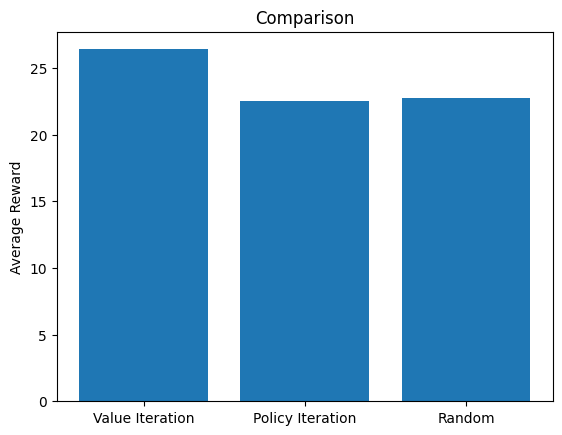

In [13]:
labels = ["Value Iteration", "Policy Iteration", "Random"]
values = [reward_vi, reward_pi, test_random_agent(env)]

plt.bar(labels, values)
plt.ylabel("Average Reward")
plt.title("Comparison")
plt.show()